In [ ]:
%pip install -q otter-grader

# In-Class Exercise 04: Hierarchical Clustering

**DS701 — Session 5 (Mon Sep 21, 2026) — Section A1**

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tools4ds/DS701-Materials-FA26/blob/main/class_activity_notebooks/04-InClass-Exercise-Hierarchical-A1/04-InClass-Exercise-Hierarchical-A1.ipynb)

**Time: ~60 minutes.** Work in groups of 2-3.

Parts marked **(autograded)** are submitted to Gradescope; open-ended parts are graded
for participation. You may use AI assistance, but you must be able to explain and
justify every part of your solution when asked.

**Plan**

| Part | Topic | Grading | Time |
|---|---|---|---|
| 1 | Build dendrograms: four linkages on one dataset | autograded | ~10 min |
| 2 | Read a dendrogram: heights, gaps, and where to cut | autograded | ~10 min |
| 3 | Flat clusters with `fcluster` and cluster sizes | autograded | ~10 min |
| 4 | **Stretch** — messy data: units, outliers, chaining; hierarchical vs $k$-means | partly autograded | ~25 min |
| 5 | Verdict for *this* dataset | participation | ~5 min |

Dependencies: `numpy`, `pandas`, `matplotlib`, `scipy`, `scikit-learn`.


## Setup

We use a real dataset this time: Fisher's **iris** measurements — sepal length, sepal
width, petal length, petal width, all in centimetres, for 150 flowers of three species.
The activity works on a **random subset of 75 flowers**.

`species` is the true species of each flower. As in every clustering exercise we **never
fit on it** — it is used only at the very end of each part to *score* a clustering, the
way a business would check a customer segmentation against a survey it ran afterwards.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score


In [4]:
# Lecture section. Only A1 runs this semester; this is kept because the build
# script reads it to name the variant directory the notebook is published in.
SECTION = "A1"
SEED = 701
rng = np.random.default_rng(SEED)


In [5]:
# Colab: fetch the autograder tests for this activity.
import os, sys, urllib.request

if "google.colab" in sys.modules:
    os.makedirs("tests", exist_ok=True)
    BASE = "https://raw.githubusercontent.com/tools4ds/DS701-Materials-FA26/main/class_activity_notebooks/04-InClass-Exercise-Hierarchical-A1/tests/"
    for _q in ("q1", "q2", "q3", "q4", "q5", "q6", "q7"):
        urllib.request.urlretrieve(BASE + _q + ".py", "tests/" + _q + ".py")


In [7]:
# Initialize Otter
import otter
grader = otter.Notebook()

In [9]:
iris = load_iris()
feature_names = [f.replace(" (cm)", "") for f in iris.feature_names]
species_names = list(iris.target_names)

# This section's subset: 75 of the 150 flowers, chosen by the section seed.
idx = np.sort(rng.choice(len(iris.data), 75, replace=False))
X = iris.data[idx]            # (75, 4) -- what the algorithms see
species = iris.target[idx]    # (75,)   -- scoring only, never fitting
n_samples = len(X)

METHODS = ["single", "complete", "average", "ward"]

print(f"Section {SECTION}: X.shape = {X.shape}")
print("flowers per species in this subset:",
      dict(zip(species_names, np.bincount(species).tolist())))
pd.DataFrame(X, columns=feature_names).describe().loc[["mean", "std", "min", "max"]].round(2)


Section A1: X.shape = (75, 4)
flowers per species in this subset: {np.str_('setosa'): 23, np.str_('versicolor'): 28, np.str_('virginica'): 24}


,sepal length,sepal width,petal length,petal width
mean,5.86,3.01,3.83,1.20
std,0.85,0.43,1.75,0.73
min,4.40,2.20,1.30,0.10
max,7.90,3.80,6.90,2.50


A quick look at the data in two of its four dimensions. Petal measurements separate the
species best; setosa (small petals) is well apart from the other two, which overlap.


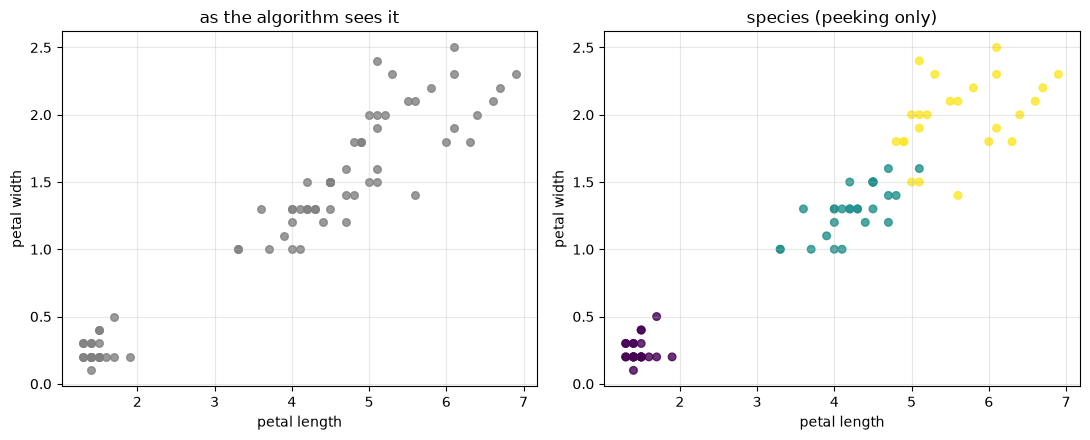

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(X[:, 2], X[:, 3], s=30, c="gray", alpha=0.8)
axes[0].set_title("as the algorithm sees it")
axes[1].scatter(X[:, 2], X[:, 3], s=30, c=species, cmap="viridis", alpha=0.8)
axes[1].set_title("species (peeking only)")
for ax in axes:
    ax.set_xlabel(feature_names[2])
    ax.set_ylabel(feature_names[3])
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Part 1 (autograded): build dendrograms with four linkages

Agglomerative clustering: start with every point as its own cluster; repeatedly merge
the two **closest** clusters; stop when one cluster remains. Everything hinges on how the
distance between two *clusters* is defined — the **linkage**:

| linkage | $D(C_i, C_j)$ | tends to |
|---|---|---|
| single | $\min_{x\in C_i,\,y\in C_j} d(x,y)$ | follow chains, find odd shapes; fragile to noise |
| complete | $\max_{x\in C_i,\,y\in C_j} d(x,y)$ | compact, similar-diameter clusters |
| average | mean of all cross-pair $d(x,y)$ | a compromise; roughly elliptical clusters |
| ward | increase in within-cluster sum of squares if merged | the hierarchical cousin of $k$-means |

`scipy.cluster.hierarchy.linkage(X, method=...)` runs the whole procedure and returns
the **linkage matrix** `Z` of shape `(n-1, 4)`: one row per merge,
`[idx1, idx2, height, count]`, where indices $\ge n$ refer to clusters created by
earlier rows and `count` is the number of original points in the new cluster.

**Task.**

1. Build `Z_by_method`, a dict mapping each name in `METHODS` to `linkage(X, method=name)`
   (Euclidean distance, the default).
2. Set `n_merges` to the number of rows of any one of these matrices, as an `int`.

Then run the plotting cell that follows and *look* at the four dendrograms before moving on.


In [11]:
Z_by_method = {name: linkage(X, method=name) for name in METHODS}
n_merges = Z_by_method["single"].shape[0]

print("n_merges =", n_merges)
print("last three merges (ward):")
print(np.round(Z_by_method["ward"][-3:], 3))


n_merges = 74
last three merges (ward):
[[142.    145.      5.801  43.   ]
 [141.    146.      9.525  52.   ]
 [143.    147.     22.117  75.   ]]


In [12]:
grader.check("q1")

q1 results: All test cases passed!

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, m in zip(axes.ravel(), METHODS):
    dendrogram(Z_by_method[m], ax=ax, no_labels=True, color_threshold=0)
    ax.set_title(f"{m} linkage")
    ax.set_ylabel("merge height")
plt.tight_layout()
plt.show()


Notice how different the four *y*-axes are — single-linkage heights are tiny (nearest
neighbours are always close), Ward's are large (it accumulates squared error). Heights
are only comparable **within** one dendrogram.


## Part 2 (autograded): read a dendrogram

The height at which two branches join is the linkage distance at that merge. Cutting the
tree with a horizontal line at height $h$ leaves every merge *below* $h$ done and every
merge *above* $h$ undone — the number of branches the line crosses is the number of clusters.

**Task.**

1. Write `n_clusters_at_height(Z, h)` returning the number of clusters obtained by
   cutting `Z` at height `h` — merges with height $\le h$ count as performed. Use only
   the linkage matrix (column 2 holds the heights); do not call `fcluster`.
   Hint: with $n$ points and no merges you have $n$ clusters, and every performed merge
   removes one.
2. For **Ward** linkage, compute the gaps between consecutive merge heights
   (`np.diff` of the heights column) and set `k_biggest_gap` to the number of clusters
   you get by cutting through the *largest* gap. Cutting between merge `i` and merge `i+1`
   (0-indexed) leaves `n_samples - 1 - i` clusters.
3. Set `h_cut_3` to a height at which the Ward tree gives **exactly three** clusters,
   and check it with your function.


In [ ]:
def n_clusters_at_height(Z, h):
    """Number of clusters when the dendrogram Z is cut at height h."""
    ...


heights_ward = Z_by_method["ward"][:, 2]
gaps_ward = np.diff(heights_ward)

...

print("largest gap between consecutive Ward merges ->", k_biggest_gap, "clusters")
print("second-largest gap ->", n_samples - 1 - int(np.argsort(gaps_ward)[-2]), "clusters")
print(f"cutting at h = {h_cut_3:.2f} gives {n_clusters_at_height(Z_by_method['ward'], h_cut_3)} clusters")

plt.figure(figsize=(9, 4))
dendrogram(Z_by_method["ward"], no_labels=True, color_threshold=h_cut_3)
plt.axhline(h_cut_3, color="red", linestyle="--", label=f"cut at {h_cut_3:.2f}")
plt.legend()
plt.title("Ward linkage, cut for 3 clusters")
plt.show()


**Discuss (participation):** the largest gap says *two* clusters, but you know there are
three species. Is the dendrogram wrong? Look at the second-largest gap and at the
petal-length/petal-width scatter above before answering.

*(1-2 sentences here)*


In [ ]:
grader.check("q2")

## Part 3 (autograded): flat clusters and their sizes

To *use* a hierarchical clustering you eventually cut it into a flat partition.
`fcluster(Z, t, criterion="maxclust")` cuts so that at most `t` clusters remain and
returns integer labels starting at **1**; `criterion="distance"` cuts at a height instead.

**Task.**

1. Write `flat_sizes(Z, k)` — cut `Z` into `k` clusters with `criterion="maxclust"` and
   return the cluster sizes as a Python list of ints, **sorted largest first**.
2. Build `sizes_k3 = {method: flat_sizes(Z_by_method[method], 3)}` for every method.
3. Build `ari_k3 = {method: adjusted_rand_score(species, labels)}`, the **Adjusted Rand
   Index** of each 3-cluster solution against the true species. ARI compares two
   partitions pair-by-pair — do two flowers land together in both, or apart in both — and
   rescales so that $1$ is a perfect match and $0$ is what a random partition would score.
   It ignores label names, so `1,2,3` vs `setosa, versicolor, virginica` is fine.


In [ ]:
def flat_sizes(Z, k):
    """Sizes of the k flat clusters (maxclust cut), largest first."""
    ...


...

pd.DataFrame({"sizes (k=3)": {m: str(v) for m, v in sizes_k3.items()},
              "ARI vs species": {m: round(v, 3) for m, v in ari_k3.items()}})


**Discuss (participation):** single linkage's three "clusters" are two big groups and a
crumb. Which two species did it fail to separate, and what in the *definition* of
single linkage explains that?

*(1-2 sentences here)*


In [ ]:
grader.check("q3")

## Part 4 (stretch): the same data, made messy

Real data is not a clean `(75, 4)` array. Below we take **the same 75 flowers** and
inject three kinds of mess, one at a time, and watch which linkages survive. The lecture
named some of these hazards; here you *produce* them on real data, then explain what you see.

- **4a** one feature recorded in different units (millimetres instead of centimetres),
- **4b** two measurement errors far from everything else (outliers) — placement differs by section,
- **4c** a thin trail of points bridging two species (a chaining-prone shape),
- **4d** the same three datasets clustered by $k$-means (last session's tool) for comparison.

You already have the tools: `linkage`, `fcluster`, `flat_sizes`, `adjusted_rand_score`.


### 4a (autograded): an unscaled feature

Suppose sepal width had been recorded in **millimetres**: `X_mm` below is `X` with column 1
multiplied by 10. Nothing about the flowers changed — only a unit.

**Task.** For **Ward** linkage cut at $k=3$, compute the ARI against `species` on three
versions of the data and store them in `ari_scale` with keys `"cm"`, `"mm"`, and
`"standardized"`:

- `"cm"` — the original `X`,
- `"mm"` — `X_mm`,
- `"standardized"` — `X_mm` after `StandardScaler().fit_transform(...)` (each column
  centred and divided by its standard deviation).


In [ ]:
X_mm = X.copy()
X_mm[:, 1] *= 10          # sepal width now in mm
X_std = StandardScaler().fit_transform(X_mm)


def ari_ward_k3(data):
    """ARI vs species of Ward linkage cut at 3 clusters."""
    ...


ari_scale = ...

for k_, v in ari_scale.items():
    print(f"Ward, k=3, {k_:>12}: ARI = {v:.3f}")


**Discuss (participation):**

1. Why does a change of *units* change the clustering at all? Point at the term in
   Ward's (or Euclidean distance's) formula that the factor of 10 enters.
2. Standardizing recovers a lot but probably not all of the `"cm"` score. Standardized data
   is unit-free, so what did the raw-cm version have going for it that standardizing threw away?

*(your answers here)*


In [ ]:
grader.check("q4")

### 4b (autograded): two outliers

Two flowers were mis-measured. `OUTLIERS` below are two points
far outside the range of the data; `X_out` appends them to `X`, so it has `n_samples + 2`
rows and the **first `n_samples` rows are the original flowers, in the same order**.

**Task.**

1. Build `sizes_out_k3 = {method: flat_sizes(linkage(X_out, method), 3)}` for all four methods.
2. Build `hijacked`, the sorted list of method names for which the smallest of the three
   clusters has **at most 2 points** — i.e. the outliers took a whole cluster for themselves.


In [ ]:
OUTLIERS = np.array([[9.5, 5.5, 8.5, 4.0], [9.8, 5.7, 8.8, 4.2]])
X_out = np.vstack([X, OUTLIERS])
print("X_out.shape =", X_out.shape)

...

for m in METHODS:
    print(f"{m:>9}: sizes at k=3 with outliers = {sizes_out_k3[m]}   (clean: {sizes_k3[m]})")
print("hijacked:", hijacked)


**Discuss (participation):** two bad rows out of 77 cost most linkages a whole cluster —
which real species got merged away to make room? Ward kept its three clusters: look at
its sizes and say where the two outliers went, and why Ward's *merge cost* makes that cheap.
What would you do about this in practice (two different fixes)?

*(your answers here)*


In [ ]:
grader.check("q5")

### 4c (autograded): a bridge, and chaining

Now a *shape* problem. `BRIDGE` is a thin trail of 12 points laid along the straight line
between the setosa centroid and the versicolor centroid — a sparse "isthmus" joining two
islands. `X_bridge` appends them to `X`; again the first `n_samples` rows are the original
flowers.

**Task.**

1. Build `sizes_bridge_k3 = {method: flat_sizes(linkage(X_bridge, method), 3)}`.
2. Build `largest_bridge = {method: <size of the largest cluster>}` from it.
3. Build `ari_bridge = {method: ARI vs species using only the first n_samples labels}` —
   the bridge points have no species, so score the original flowers only.


In [ ]:
_rng_bridge = np.random.default_rng(SEED + 1)
_c_setosa = X[species == 0].mean(axis=0)
_c_versicolor = X[species == 1].mean(axis=0)
BRIDGE = np.array([_c_setosa + t * (_c_versicolor - _c_setosa) for t in np.linspace(0.1, 0.9, 12)])
BRIDGE += _rng_bridge.normal(0, 0.03, BRIDGE.shape)
X_bridge = np.vstack([X, BRIDGE])
print("X_bridge.shape =", X_bridge.shape)

...

pd.DataFrame({"sizes (k=3, with bridge)": {m: str(v) for m, v in sizes_bridge_k3.items()},
              "largest": largest_bridge,
              "ARI on original flowers": {m: round(v, 3) for m, v in ari_bridge.items()},
              "ARI clean (Part 3)": {m: round(v, 3) for m, v in ari_k3.items()}})


**Discuss (participation):** single linkage went from "two big groups and a crumb" to
*one* group and crumbs. Explain the collapse using the $\min$ in its definition. Why did
complete linkage barely notice the bridge? (Which cross-cluster distance does the bridge
change for `single`, and which does it leave alone for `complete`?)

*(your answers here)*


In [ ]:
grader.check("q6")

### 4d (autograded): hierarchical vs $k$-means on the same three datasets

Last session's tool on this session's mess. For each of the three datasets, fit
`KMeans(n_clusters=3, n_init=10, random_state=SEED)` and score it against `species` on
the **first `n_samples` rows** (the original flowers), then compare against the *best*
hierarchical linkage on that dataset.

**Task.**

1. `ari_kmeans = {name: ARI of k-means on DATASETS[name], original rows only}` for the
   three names in `DATASETS`.
2. `ari_best_hier = {name: max over the four linkages of the same score}` — reuse
   `ari_k3` for `"clean"`, `ari_bridge` for `"bridge"`, and compute the outlier case
   here (`X_out`, first `n_samples` labels).
3. `kmeans_wins = sorted(name for name in DATASETS if ari_kmeans[name] > ari_best_hier[name])`.


In [ ]:
DATASETS = {"clean": X, "outliers": X_out, "bridge": X_bridge}

...

pd.DataFrame({"k-means": ari_kmeans, "best hierarchical": ari_best_hier}).round(3)


**Discuss (participation):** $k$-means barely moved across the three datasets, while the
hierarchical methods swung wildly by linkage. What property of $k$-means makes it shrug
off two outliers and a thin bridge here — and what did it need from you that hierarchical
clustering did not?

*(your answers here)*


In [ ]:
grader.check("q7")

<!-- BEGIN QUESTION -->

## Part 5 (participation): the verdict for *this* dataset

Write your group's recommendation for **your section's** iris subset, citing numbers
from your notebook:

1. Which linkage would you use for these 75 flowers, and why — name the specific
   evidence (sizes, ARI, a dendrogram gap) that rules the others out.
2. Which of the three kinds of mess (units, outliers, bridge) would change your
   recommendation, and to what?
3. Would $k$-means have been fine here? What would you have had to know or assume to
   use it, and when in general would you reach for a dendrogram instead?

> Staff will visit tables during this part. Be ready to explain your reasoning and to
> point at the cell that supports each claim.


_Type your answer here, replacing this text._

<!-- END QUESTION -->

## Wrap-up

Before you leave, each group should be able to answer, without notes:

1. What does the height of a merge in a dendrogram mean, and why can't you compare
   heights across two dendrograms built with different linkages?
2. Which linkage chains, and what one-word feature of its definition causes it?
3. What did the dendrogram show you about the outliers that $k$-means never would?

Submit the autograded parts (1–4d) to Gradescope.
